# Multi-equilibrium density vs. pedestal pressure ratio

For each successfully converged run in `multiequil_kbmavg` (`success.npy`), extract the final electron density at the pedestal boundaries (`psiN = 0.85` and `psiN = 1`) and plot against `p_pedestal_predicted / p_pedestal_experiment` (`ped_h / (p_gfile / 1e6)`).

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from pathlib import Path

In [2]:
# Inputs
out_dir = Path('multiequil_kbmavg')
psiN_inner = 0.85
psiN_outer = 1.0

In [3]:
success = np.load(out_dir / 'success.npy', allow_pickle=True)
print(f'{len(success)} successful equilibria')

97 successful equilibria


In [4]:
def last_ne_iter(eq_dir: Path):
    """Return path to the highest-index ne_iter_*.npy in eq_dir."""
    iters = list(eq_dir.glob('ne_iter_*.npy'))
    if not iters:
        return None
    return max(iters, key=lambda p: int(p.stem.split('_')[-1]))


def ne_at_psiN(sol, psiN, psiN_inner=0.85, psiN_outer=1.0):
    """
    Map converged ne(x) onto psiN.

    The density solver domain runs from psiN_inner (x = x[0]) to
    psiN_outer / separatrix (x = 0 = x[-1]). Interpolate linearly in x
    after mapping the requested psiN onto that radial coordinate.
    """
    x = np.asarray(sol['x'], dtype=float)
    ne = np.asarray(sol['y'], dtype=float)
    # Linear map psiN -> x using the known endpoints of the solve domain
    x_at_psi = np.interp(psiN, [psiN_inner, psiN_outer], [x[0], x[-1]])
    return float(np.interp(x_at_psi, x, ne))


ne_inner = []
ne_outer = []
p_ratio = []
tags = []

for out_dict in success:
    equil_tag = Path(out_dict['mhd_fp']).name[1:]  # g152960.03500 -> 152960.03500
    eq_dir = out_dir / equil_tag
    npy_path = last_ne_iter(eq_dir)
    if npy_path is None:
        print(f'skipping {equil_tag}: no ne_iter files')
        continue

    sol = np.load(npy_path, allow_pickle=True).item()
    # ped_h [MPa], p_gfile [Pa] — same convention as plot_epednn_multieq_profilesloop.ipynb
    ratio = out_dict['ped_h'] / (out_dict['p_gfile'] / 1e6)

    ne_inner.append(ne_at_psiN(sol, psiN_inner, psiN_inner, psiN_outer))
    ne_outer.append(ne_at_psiN(sol, psiN_outer, psiN_inner, psiN_outer))
    p_ratio.append(ratio)
    tags.append(equil_tag)

ne_inner = np.asarray(ne_inner)
ne_outer = np.asarray(ne_outer)
p_ratio = np.asarray(p_ratio)
print(f'extracted densities for {len(p_ratio)} equilibria')

extracted densities for 97 equilibria


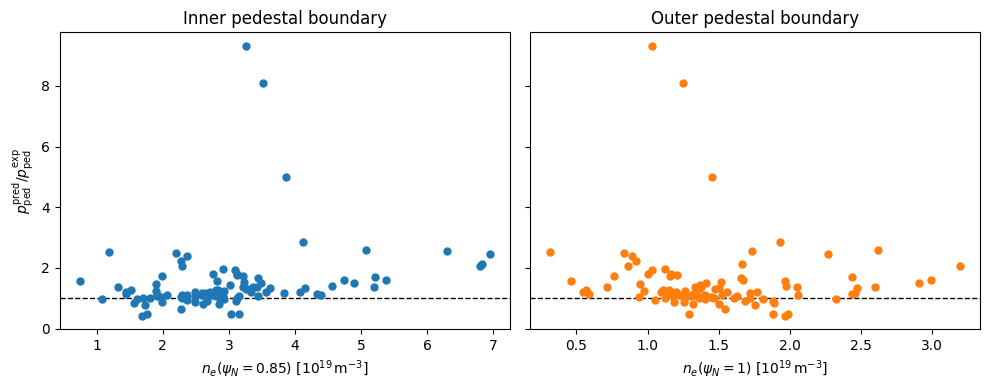

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(ne_inner / 1e19, p_ratio, 'o', color='tab:blue', ms=5)
axes[0].set_xlabel(r'$n_e(\psi_N = 0.85)$ [$10^{19}\,\mathrm{m}^{-3}$]')
axes[0].set_ylabel(r'$p_{\mathrm{ped}}^{\mathrm{pred}} / p_{\mathrm{ped}}^{\mathrm{exp}}$')
axes[0].set_title('Inner pedestal boundary')
axes[0].axhline(1.0, color='k', ls='--', lw=1, zorder=0)

axes[1].plot(ne_outer / 1e19, p_ratio, 'o', color='tab:orange', ms=5)
axes[1].set_xlabel(r'$n_e(\psi_N = 1)$ [$10^{19}\,\mathrm{m}^{-3}$]')
axes[1].set_title('Outer pedestal boundary')
axes[1].axhline(1.0, color='k', ls='--', lw=1, zorder=0)

fig.tight_layout()
plt.show()

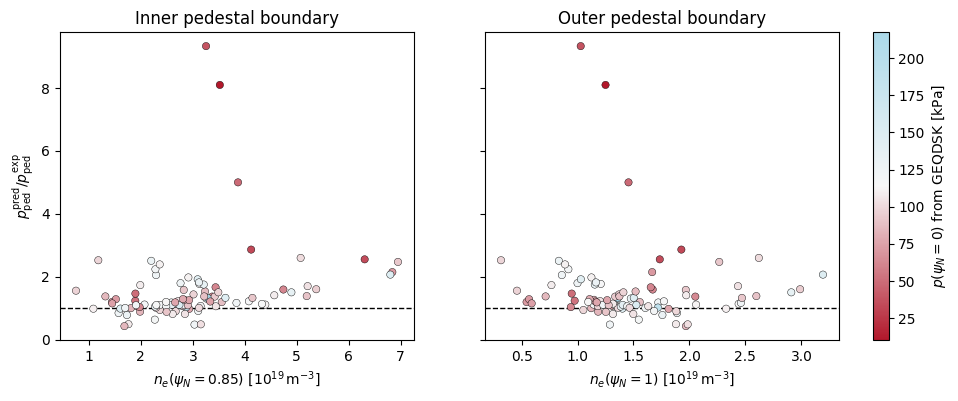

In [15]:
# Same plots, colored by GEQDSK p(psiN≈0) from CAKEgeqdsks
geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks')


def p_at_psiN0(mhd_fp):
    """Return GEQDSK pressure [Pa] at psiN=0 (magnetic axis), or nearest grid point."""
    with open(mhd_fp, 'r') as fid:
        line = fid.readline()
        nr = int(line[48:].split()[-2])
        # Skip 4 header lines (rdim/zdim/... through second skip block)
        for _ in range(4):
            fid.readline()

        def read_1d(n):
            vals = np.zeros(n)
            j = 0
            line = ''
            for i in range(n):
                if j == 0:
                    line = fid.readline()
                vals[i] = float(line[j:j + 16])
                j += 16
                if j == 16 * 5:
                    j = 0
            return vals

        _fpol = read_1d(nr)
        pres = read_1d(nr)

    psi_N = np.linspace(0.0, 1.0, nr)
    # Exact axis value is psi_N[0]; interp still picks the nearest grid point if needed
    return float(np.interp(0.0, psi_N, pres))


p_axis = []
for tag in tags:
    mhd_fp = geqdsk_dir / f'g{tag}'
    if not mhd_fp.exists():
        # Fall back to path stored in success.npy
        match = next(s for s in success if Path(s['mhd_fp']).name[1:] == tag)
        mhd_fp = Path(match['mhd_fp'])
    p_axis.append(p_at_psiN0(mhd_fp))
p_axis = np.asarray(p_axis)

from matplotlib.colors import LinearSegmentedColormap
# Red (low p) -> white -> light blue (high p); stop before RdBu's dark-blue end
cmap_red_lightblue = LinearSegmentedColormap.from_list(
    'red_lightblue',
    ['#b2182b', '#f7f7f7', '#abd9e9'],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

sc0 = axes[0].scatter(
    ne_inner / 1e19, p_ratio, c=p_axis / 1e3, cmap=cmap_red_lightblue, s=28, edgecolors='k', linewidths=0.3,
)
axes[0].set_xlabel(r'$n_e(\psi_N = 0.85)$ [$10^{19}\,\mathrm{m}^{-3}$]')
axes[0].set_ylabel(r'$p_{\mathrm{ped}}^{\mathrm{pred}} / p_{\mathrm{ped}}^{\mathrm{exp}}$')
axes[0].set_title('Inner pedestal boundary')
axes[0].axhline(1.0, color='k', ls='--', lw=1, zorder=0)

sc1 = axes[1].scatter(
    ne_outer / 1e19, p_ratio, c=p_axis / 1e3, cmap=cmap_red_lightblue, s=28, edgecolors='k', linewidths=0.3,
)
axes[1].set_xlabel(r'$n_e(\psi_N = 1)$ [$10^{19}\,\mathrm{m}^{-3}$]')
axes[1].set_title('Outer pedestal boundary')
axes[1].axhline(1.0, color='k', ls='--', lw=1, zorder=0)

cbar = fig.colorbar(sc1, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label(r'$p(\psi_N=0)$ from GEQDSK [kPa]')

# fig.tight_layout()
plt.show()


In [16]:
# Shots with p_pred / p_exp > 4
mask = p_ratio > 4
high_ratio = sorted(
    zip(np.asarray(tags)[mask], p_ratio[mask]),
    key=lambda t: t[1],
    reverse=True,
)
print(f'{len(high_ratio)} equilibria with p_pred/p_exp > 4:\n')
for tag, ratio in high_ratio:
    shot = tag.split('.')[0]
    print(f'  shot {shot}  ({tag})  p_pred/p_exp = {ratio:.3f}')


3 equilibria with p_pred/p_exp > 4:

  shot 154929  (154929.02200)  p_pred/p_exp = 9.324
  shot 154959  (154959.02500)  p_pred/p_exp = 8.091
  shot 154521  (154521.02800)  p_pred/p_exp = 4.995


In [11]:
# Shots with p_pred / p_exp < 1.2 and > 1
mask = (p_ratio > 1) & (p_ratio < 1.2)
high_ratio = sorted(
    zip(np.asarray(tags)[mask], p_ratio[mask]),
    key=lambda t: t[1],
    reverse=True,
)
print(f'{len(high_ratio)} equilibria with p_pred/p_exp > 1 and < 1.2:\n')
for tag, ratio in high_ratio:
    shot = tag.split('.')[0]
    print(f'  shot {shot}  ({tag})  ratio = {ratio:.3f}')

29 equilibria with p_pred/p_exp > 1 and < 1.2:

  shot 158091  (158091.01935)  ratio = 1.194
  shot 157109  (157109.01963)  ratio = 1.192
  shot 153826  (153826.02950)  ratio = 1.190
  shot 158084  (158084.02850)  ratio = 1.182
  shot 153489  (153489.01800)  ratio = 1.177
  shot 156864  (156864.03600)  ratio = 1.165
  shot 157191  (157191.02060)  ratio = 1.149
  shot 157375  (157375.02000)  ratio = 1.140
  shot 153831  (153831.02500)  ratio = 1.133
  shot 154853  (154853.04015)  ratio = 1.112
  shot 153830  (153830.02500)  ratio = 1.111
  shot 157381  (157381.03200)  ratio = 1.105
  shot 157376  (157376.02000)  ratio = 1.103
  shot 154849  (154849.02075)  ratio = 1.100
  shot 158036  (158036.03085)  ratio = 1.100
  shot 157373  (157373.02110)  ratio = 1.097
  shot 157371  (157371.02000)  ratio = 1.091
  shot 158071  (158071.03500)  ratio = 1.090
  shot 152960  (152960.03500)  ratio = 1.075
  shot 153828  (153828.02500)  ratio = 1.069
  shot 154863  (154863.05500)  ratio = 1.062
  shot 